# Exploratory Data Analysis: Decision Paths in E-commerce Sessions

This notebook explores session-level decision paths in a semi-synthetic
e-commerce clickstream dataset.

Focus:
- How users progress toward purchase or exit
- How path length and hesitation relate to conversion
- Whether high activity implies high intent

In [37]:
import os

# ensure working directory is repo root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Current working directory:", os.getcwd())

Current working directory: /Users/daviewu/Study/me/behavior-state-modeling


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

In [39]:
events = pd.read_csv("data/sample/v0_1/events_sample.csv")
sessions = pd.read_csv("data/sample/v0_1/sessions_sample.csv")

events.head(), sessions.head()

(    user_id   session_id                    timestamp  event_index  \
 0  u_000000  s_7_0000001  2025-11-28T05:40:43.018250Z            0   
 1  u_000000  s_7_0000001  2025-11-28T05:40:59.033918Z            1   
 2  u_000000  s_7_0000001  2025-11-28T05:41:09.990216Z            2   
 3  u_000000  s_7_0000001  2025-11-28T05:41:23.552493Z            3   
 4  u_000000  s_7_0000001  2025-11-28T05:41:58.841175Z            4   
 
       event_type      item_id category   price price_bucket  dwell_time_s  \
 0        compare  item_004288    pants   51.39       50_100         5.352   
 1      item_view  item_005963   beauty   15.84         0_20        11.734   
 2  category_view  item_003213     home  125.49      100_200         8.113   
 3      item_view  item_009567     tops   12.63         0_20        10.801   
 4        compare  item_009248    pants   38.19        20_50         8.680   
 
    gap_time_s referrer   device  state_true  is_noise  
 0       0.000   search  desktop  evaluating 

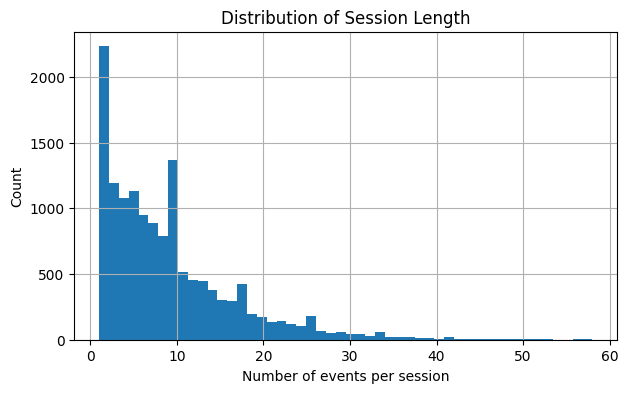

In [40]:
sessions["n_events"].describe()

plt.hist(sessions["n_events"], bins=50)
plt.xlabel("Number of events per session")
plt.ylabel("Count")
plt.title("Distribution of Session Length")
plt.show()

In [41]:
sessions["n_events"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    14039.000000
mean         9.090320
std          7.616781
min          1.000000
50%          7.000000
75%         12.000000
90%         19.000000
95%         24.000000
99%         36.000000
max         58.000000
Name: n_events, dtype: float64

**Observation (Session Length):**  
Session length is strongly right-skewed. Half of all sessions contain 7 events or fewer, and 75% finish within 12 events. While a long tail exists (up to 58 events), extremely long sessions are rare (only ~1% exceed 36 events). This suggests that most user decision processes are relatively short, with a small minority exhibiting prolonged interaction sequences.

In [42]:
sessions.groupby("conversion")["n_events"].describe()

,count,mean,std,min,25%,50%,75%,max
conversion,,,,,,,,
0,11945.0,9.036501,7.669147,1.0,3.0,7.0,12.0,58.0
1,2094.0,9.397326,7.305085,2.0,4.0,7.0,12.0,52.0


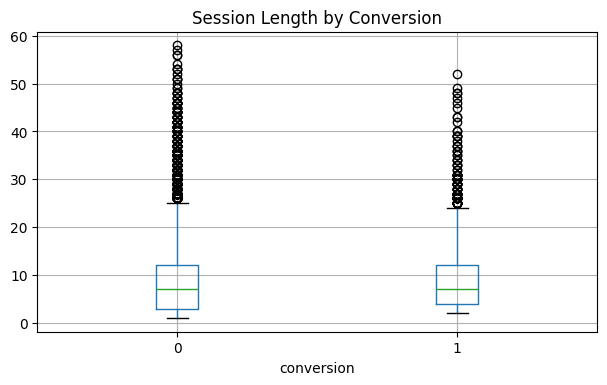

In [43]:
sessions.boxplot(column="n_events", by="conversion")
plt.title("Session Length by Conversion")
plt.suptitle("")
plt.show()

**Finding 1 (Path Length vs Conversion):**  
Session length alone does not meaningfully distinguish converted from non-converted sessions. Both groups share nearly identical median and interquartile ranges, suggesting that longer interaction sequences do not necessarily indicate higher purchase intent.

In [44]:
first_cart = (
    events[events["event_type"] == "add_to_cart"]
    .groupby("session_id")["event_index"]
    .min()
)

first_cart.head()

session_id
s_7_0000005    1
s_7_0000006    2
s_7_0000008    1
s_7_0000011    0
s_7_0000012    5
Name: event_index, dtype: int64

In [45]:
sessions = sessions.merge(
    first_cart.rename("first_cart_index"),
    on="session_id",
    how="left"
)

sessions[["session_id", "n_events", "first_cart_index"]].head()

,session_id,n_events,first_cart_index
0,s_7_0000001,18,NaN
1,s_7_0000002,3,NaN
2,s_7_0000003,3,NaN
3,s_7_0000004,7,NaN
4,s_7_0000005,18,1.0


In [46]:
sessions["first_cart_ratio"] = (
    sessions["first_cart_index"] / sessions["n_events"]
)
sessions[["first_cart_index", "first_cart_ratio"]].describe()

,first_cart_index,first_cart_ratio
count,5974.000000,5974.000000
mean,4.317543,0.315758
std,4.631772,0.252270
min,0.000000,0.000000
25%,1.000000,0.100000
50%,3.000000,0.277778
75%,6.000000,0.500000
max,37.000000,0.966667


**Observation (First Add-to-Cart Position):**  
Among sessions that contain at least one add-to-cart action, the timing of the first cart event varies substantially. The median first-cart position occurs at ~28% of the session length, with a wide spread across sessions, indicating heterogeneous commitment timing even among users who eventually express purchase intent.

In [47]:
sessions_with_cart = sessions.dropna(subset=["first_cart_ratio"])
sessions_with_cart.groupby("conversion")["first_cart_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
conversion,,,,,,,,
0,5097.0,0.322580,0.255545,0.0,0.100000,0.285714,0.500000,0.966667
1,877.0,0.276109,0.228457,0.0,0.083333,0.250000,0.428571,0.888889


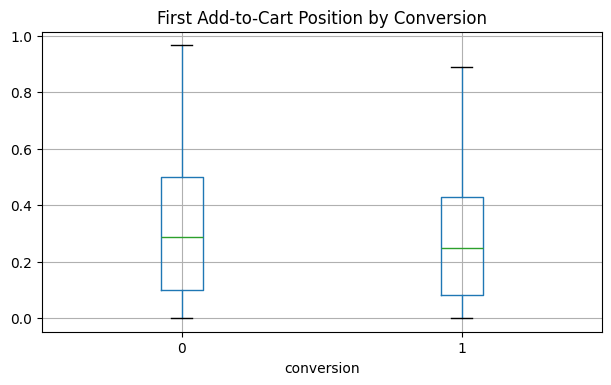

In [48]:
sessions_with_cart.boxplot(
    column="first_cart_ratio",
    by="conversion"
)
plt.title("First Add-to-Cart Position by Conversion")
plt.suptitle("")
plt.show()

**Finding 2 (Commitment Timing):**  
Among sessions that include an add-to-cart action, converted sessions tend to initiate cart addition earlier in their decision paths. While the distributions overlap substantially, the consistent leftward shift in the median and interquartile range suggests that earlier commitment is associated with a higher likelihood of conversion, albeit with a modest effect size.

## Decision Path Structure (v1)

In [49]:
top_paths = (
    sessions["path_signature"]
    .value_counts()
    .head(15)
)

top_paths

path_signature
exit                              1024
item_view->exit                    329
purchase->exit                     185
category_view->exit                180
category_view->item_view->exit     124
search->exit                       110
item_view->item_view->exit         109
add_to_cart->exit                   88
compare->exit                       86
wishlist->exit                      78
search->item_view->exit             73
item_view->purchase->exit           63
item_view->add_to_cart->exit        60
landing->exit                       60
item_view->wishlist->exit           59
Name: count, dtype: int64

In [50]:
path_conv = (
    sessions
    .groupby("path_signature")["conversion"]
    .agg(["count", "mean"])
    .sort_values("count", ascending=False)
    .head(15)
)

path_conv

,count,mean
path_signature,,
exit,1024,0.0
item_view->exit,329,0.0
purchase->exit,185,1.0
category_view->exit,180,0.0
category_view->item_view->exit,124,0.0
search->exit,110,0.0
item_view->item_view->exit,109,0.0
add_to_cart->exit,88,0.0
compare->exit,86,0.0


In [51]:
decision_sessions = sessions[
    (sessions["n_events"] >= 3) &
    (sessions["path_signature"] != "exit")
]

decision_sessions.shape

(11808, 21)

In [52]:
decision_top_paths = (
    decision_sessions["path_signature"]
    .value_counts()
    .head(15)
)

decision_top_paths

path_signature
category_view->item_view->exit               124
item_view->item_view->exit                   109
search->item_view->exit                       73
item_view->purchase->exit                     63
item_view->add_to_cart->exit                  60
item_view->wishlist->exit                     59
category_view->item_view->item_view->exit     52
item_view->compare->exit                      52
search->category_view->exit                   37
item_view->item_view->item_view->exit         36
category_view->purchase->exit                 36
landing->item_view->exit                      35
category_view->item_view->compare->exit       33
item_view->checkout_start->exit               33
item_view->item_view->compare->exit           31
Name: count, dtype: int64

### Candidate Decision Path Prototypes 

Based on frequency inspection of decision-relevant sessions, we observe several recurring structural patterns:

1. Browsing-only paths:
   Repeated category and item views followed by exit, without explicit commitment actions.

2. Commitment-touch paths:
   Item views followed by add-to-cart, checkout start, or purchase, then exit.

3. Comparison-augmented paths:
   Item or category views with one or more comparison actions before exit.

These prototypes are defined structurally and will be used to group session paths in subsequent analysis.

### Path Type Classification (v1)
We define three rule-based decision path types based on whether a path contains commitment actions (add_to_cart/checkout_start/purchase) or comparison actions (compare). This converts raw path signatures into interpretable categories for downstream analysis.

In [53]:
def classify_path_signature(sig: str) -> str:
    tokens = sig.split("->")

    has_purchase = "purchase" in tokens
    has_checkout = "checkout_start" in tokens
    has_cart = "add_to_cart" in tokens
    has_commit = has_purchase or has_checkout or has_cart

    has_compare = "compare" in tokens

    # priority: commitment > comparison > browsing
    if has_commit:
        return "commitment_touch"
    if has_compare:
        return "comparison_augmented"
    return "browsing_only"


decision_sessions = sessions[
    (sessions["n_events"] >= 3) &
    (sessions["path_signature"] != "exit")
].copy()

decision_sessions["path_type"] = decision_sessions["path_signature"].apply(classify_path_signature)

decision_sessions["path_type"].value_counts()

path_type
commitment_touch        7467
browsing_only           2684
comparison_augmented    1657
Name: count, dtype: int64

In [54]:
decision_sessions.groupby("path_type")[["n_events", "hesitation_index", "conversion"]].mean().sort_values("conversion", ascending=False)

,n_events,hesitation_index,conversion
path_type,,,
commitment_touch,10.163787,0.131640,0.239855
browsing_only,11.566692,0.107803,0.029434
comparison_augmented,10.406156,0.238091,0.023537


In [55]:
commitment_sessions = decision_sessions[
    decision_sessions["path_type"] == "commitment_touch"
].copy()

commitment_sessions.shape
commitment_sessions["first_cart_ratio"].describe()

median_ratio = commitment_sessions["first_cart_ratio"].median()

commitment_sessions["commitment_timing"] = np.where(
    commitment_sessions["first_cart_ratio"] <= median_ratio,
    "early_commitment",
    "late_commitment"
)

commitment_sessions["commitment_timing"].value_counts()

commitment_sessions.groupby("commitment_timing")[
    ["conversion", "n_events", "hesitation_index"]
].mean()

,conversion,n_events,hesitation_index
commitment_timing,,,
early_commitment,0.175734,11.244618,0.129199
late_commitment,0.273208,9.601588,0.132909


**Finding 4 (Early vs Late Commitment within Commitment Paths):**  
Within commitment-touch paths, sessions that commit later in the decision process exhibit higher conversion rates than those that commit early. Early-commitment sessions tend to have longer post-commit interaction sequences, suggesting tentative or exploratory commitment, whereas late-commitment sessions appear to consolidate decisions before committing and proceed more efficiently to purchase.

In [56]:
decision_sessions["commitment_timing"] = np.where(
    decision_sessions["first_cart_ratio"].notna() &
    (decision_sessions["first_cart_ratio"] <= median_ratio),
    "early_commitment",
    np.where(
        decision_sessions["first_cart_ratio"].notna(),
        "late_commitment",
        "no_commitment"
    )
)

decision_sessions["path_commitment_group"] = (
    decision_sessions["path_type"] + " | " +
    decision_sessions["commitment_timing"]
)

decision_sessions["path_commitment_group"].value_counts()

decision_sessions.groupby("path_commitment_group")[
    ["conversion", "n_events", "hesitation_index"]
].agg(
    conversion_rate=("conversion", "mean"),
    avg_events=("n_events", "mean"),
    avg_hesitation=("hesitation_index", "mean"),
    sessions=("conversion", "count")
).sort_values("sessions", ascending=False)

,conversion_rate,avg_events,avg_hesitation,sessions
path_commitment_group,,,,
commitment_touch | early_commitment,0.175734,11.244618,0.129199,2555
commitment_touch | late_commitment,0.128429,11.135984,0.140623,2515
commitment_touch | no_commitment,0.425115,7.991656,0.124816,2397
browsing_only | no_commitment,0.003327,6.005228,0.096684,2104
comparison_augmented | no_commitment,0.004222,8.133709,0.247259,1421
browsing_only | early_commitment,0.122324,32.712538,0.146322,327
browsing_only | late_commitment,0.126482,30.486166,0.150479,253
comparison_augmented | early_commitment,0.124088,24.437956,0.180410,137
comparison_augmented | late_commitment,0.161616,23.606061,0.186319,99


## Decision Path Framework (Path Structure × Commitment Timing)

A two-dimensional framework combining path structure and commitment timing reveals that:

- Sessions without any commitment actions almost never convert, regardless of browsing intensity.
- Comparison-augmented paths exhibit higher hesitation but remain low-conversion, suggesting decision friction.
- Commitment-touch paths represent a structural shift toward conversion, but not all commitments are equal.
- Sessions that proceed directly to checkout or purchase without intermediate cart actions show the highest conversion rates and the shortest paths, indicating decisive commitment.
- Early add-to-cart actions followed by prolonged interaction are associated with lower conversion, suggesting tentative or reversible commitment.

This framework highlights that *what type of commitment occurs* is more important than *how early* it occurs.

In [57]:
def classify_commitment_strength(sig: str) -> str:
    tokens = sig.split("->")

    if "purchase" in tokens or "checkout_start" in tokens:
        return "hard_commitment"
    if "add_to_cart" in tokens:
        return "soft_commitment"
    return "no_commitment"


decision_sessions["commitment_strength"] = (
    decision_sessions["path_signature"]
    .apply(classify_commitment_strength)
)

decision_sessions["commitment_strength"].value_counts()

commitment_strength
hard_commitment    4660
no_commitment      4341
soft_commitment    2807
Name: count, dtype: int64

In [58]:
soft_commitment_sessions = decision_sessions[
    decision_sessions["commitment_strength"] == "soft_commitment"
].copy()

soft_commitment_sessions["soft_commitment_timing"] = np.where(
    soft_commitment_sessions["first_cart_ratio"] <=
    soft_commitment_sessions["first_cart_ratio"].median(),
    "early_soft_commitment",
    "late_soft_commitment"
)

soft_commitment_sessions["soft_commitment_timing"].value_counts()

soft_commitment_timing
early_soft_commitment    1418
late_soft_commitment     1389
Name: count, dtype: int64

In [61]:
decision_sessions["soft_commitment_timing"] = pd.Series(
    index=decision_sessions.index,
    dtype="object"
)

decision_sessions.loc[
    decision_sessions["commitment_strength"] == "soft_commitment",
    "soft_commitment_timing"
] = soft_commitment_sessions["soft_commitment_timing"].values

decision_sessions[
    decision_sessions["commitment_strength"] == "soft_commitment"
][["soft_commitment_timing"]].head()

decision_sessions["enhanced_group"] = np.where(
    decision_sessions["commitment_strength"] == "hard_commitment",
    "hard_commitment",
    np.where(
        decision_sessions["commitment_strength"] == "soft_commitment",
        decision_sessions["soft_commitment_timing"],
        "no_commitment"
    )
)

decision_sessions["enhanced_group"].value_counts()

enhanced_summary = (
    decision_sessions
    .groupby("enhanced_group")[["conversion", "n_events", "hesitation_index"]]
    .agg(
        conversion_rate=("conversion", "mean"),
        avg_events=("n_events", "mean"),
        avg_hesitation=("hesitation_index", "mean"),
        sessions=("conversion", "count")
    )
    .sort_values("sessions", ascending=False)
)

enhanced_summary

,conversion_rate,avg_events,avg_hesitation,sessions
enhanced_group,,,,
hard_commitment,0.371674,9.799356,0.125490,4660
no_commitment,0.027183,11.123704,0.157535,4341
early_soft_commitment,0.026798,11.058533,0.137972,1418
late_soft_commitment,0.015119,10.473002,0.145806,1389


### Key Findings: Refined Commitment Semantics

Refining commitment semantics reveals a clear hierarchy in decision effectiveness:

- Hard commitment actions (checkout or purchase) represent a decisive behavioral boundary, yielding the highest conversion rates (~37%) alongside shorter paths and lower hesitation.
- Soft commitment actions (add-to-cart), regardless of timing, do not significantly improve conversion outcomes and resemble non-commitment behavior in both hesitation and efficiency.
- This distinction demonstrates that not all commitment signals are equally informative; the *strength* of commitment matters more than its *timing*.

These results highlight the importance of distinguishing between tentative and decisive user actions when modeling decision behavior.

# Final Findings (v1)

1. Path length alone does not distinguish conversion outcomes.
2. Decision path structure provides a strong separation of user intent.
3. Commitment-touch paths exhibit an order-of-magnitude higher conversion rate than non-commitment paths.
4. Add-to-cart represents a weak (soft) commitment signal and does not reliably indicate conversion intent.
5. Hard commitment actions (checkout or purchase) form a decisive behavioral boundary with the highest conversion efficiency.


In [60]:
# Start from enhanced_summary (index = enhanced_group)
enh = enhanced_summary.copy()

# Combine soft commitment groups
soft_sessions = enh.loc[["early_soft_commitment", "late_soft_commitment"], "sessions"].sum()
soft_conv = (
    enh.loc["early_soft_commitment", "conversion_rate"] * enh.loc["early_soft_commitment", "sessions"] +
    enh.loc["late_soft_commitment", "conversion_rate"] * enh.loc["late_soft_commitment", "sessions"]
) / soft_sessions
soft_events = (
    enh.loc["early_soft_commitment", "avg_events"] * enh.loc["early_soft_commitment", "sessions"] +
    enh.loc["late_soft_commitment", "avg_events"] * enh.loc["late_soft_commitment", "sessions"]
) / soft_sessions
soft_hes = (
    enh.loc["early_soft_commitment", "avg_hesitation"] * enh.loc["early_soft_commitment", "sessions"] +
    enh.loc["late_soft_commitment", "avg_hesitation"] * enh.loc["late_soft_commitment", "sessions"]
) / soft_sessions

framework = pd.DataFrame({
    "group": [
        "Browsing-only (no commitment)",
        "Comparison-augmented (no commitment)",
        "Soft commitment (add_to_cart)",
        "Hard commitment (checkout/purchase)",
    ],
    "conversion_rate": [
        float(decision_sessions.query("path_type=='browsing_only' and commitment_strength=='no_commitment'")["conversion"].mean()),
        float(decision_sessions.query("path_type=='comparison_augmented' and commitment_strength=='no_commitment'")["conversion"].mean()),
        float(soft_conv),
        float(enh.loc["hard_commitment", "conversion_rate"]),
    ],
    "avg_events": [
        float(decision_sessions.query("path_type=='browsing_only' and commitment_strength=='no_commitment'")["n_events"].mean()),
        float(decision_sessions.query("path_type=='comparison_augmented' and commitment_strength=='no_commitment'")["n_events"].mean()),
        float(soft_events),
        float(enh.loc["hard_commitment", "avg_events"]),
    ],
    "avg_hesitation": [
        float(decision_sessions.query("path_type=='browsing_only' and commitment_strength=='no_commitment'")["hesitation_index"].mean()),
        float(decision_sessions.query("path_type=='comparison_augmented' and commitment_strength=='no_commitment'")["hesitation_index"].mean()),
        float(soft_hes),
        float(enh.loc["hard_commitment", "avg_hesitation"]),
    ],
    "sessions": [
        int(decision_sessions.query("path_type=='browsing_only' and commitment_strength=='no_commitment'").shape[0]),
        int(decision_sessions.query("path_type=='comparison_augmented' and commitment_strength=='no_commitment'").shape[0]),
        int(soft_sessions),
        int(enh.loc["hard_commitment", "sessions"]),
    ]
})

framework

,group,conversion_rate,avg_events,avg_hesitation,sessions
0,Browsing-only (no commitment),0.029434,11.566692,0.107803,2684
1,Comparison-augmented (no commitment),0.023537,10.406156,0.238091,1657
2,Soft commitment (add_to_cart),0.021019,10.768792,0.141848,2807
3,Hard commitment (checkout/purchase),0.371674,9.799356,0.125490,4660
